In [3]:
import pandas as pd
df = pd.read_csv('score.csv')
df.head()

,studend_id,study_hours,attendance,assignment_score,sleep_hours,final_score
0,1,2.0,75.0,68.0,6.5,74.0
1,2,3.5,88.0,82.0,6.0,81.0
2,3,1.5,72.0,65.0,7.0,70.0
3,4,4.0,90.0,88.0,6.5,84.0
4,5,5.0,95.0,92.0,6.0,89.0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

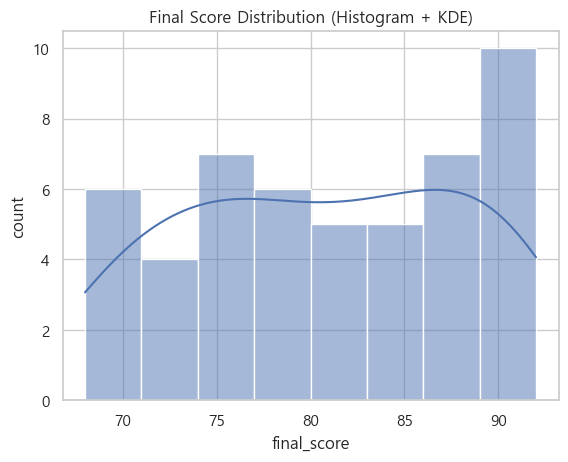

In [12]:
plt.figure()
sns.histplot(
    df['final_score'],
    bins=8,
    kde=True #확률밀도 곡선추가
)
plt.title('Final Score Distribution (Histogram + KDE)')
plt.xlabel('final_score')
plt.ylabel('count')
plt.show()

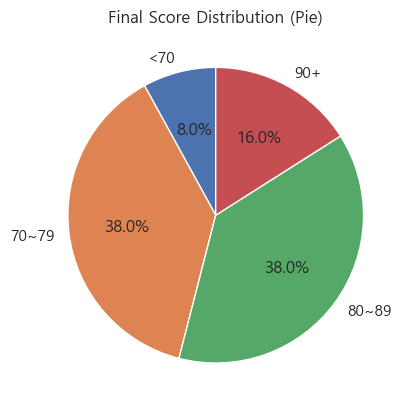

In [18]:
bins = [0,69,79,89,100]
labels = ['<70','70~79','80~89','90+']

score_group = pd.cut(df['final_score'], bins=bins, labels=labels) #구간별로 나누어주고
score_count = score_group.value_counts().sort_index() #집계 및 정렬

plt.figure()
plt.pie(
    score_count,
    labels=score_count.index,
    autopct='%.1f%%',
    startangle=90 #90도부터 시작(미입력시 0도부터)
)
plt.title('Final Score Distribution (Pie)')
plt.show()

In [20]:
score_group = pd.cut(df['final_score'], bins=bins, labels=labels)
print(score_group)

0     70~79
1     80~89
2     70~79
3     80~89
4     80~89
5     70~79
6     70~79
7       <70
8     80~89
9       90+
10    70~79
11    80~89
12    80~89
13    70~79
14      90+
15    80~89
16    70~79
17    80~89
18      <70
19      90+
20    70~79
21    80~89
22    80~89
23    70~79
24      90+
25    70~79
26    70~79
27    80~89
28    70~79
29      90+
30    70~79
31    80~89
32    80~89
33      <70
34      90+
35    70~79
36    80~89
37    80~89
38    70~79
39      90+
40    70~79
41    80~89
42    80~89
43      <70
44      90+
45    70~79
46    70~79
47    80~89
48    70~79
49    80~89
Name: final_score, dtype: category
Categories (4, object): ['<70' < '70~79' < '80~89' < '90+']


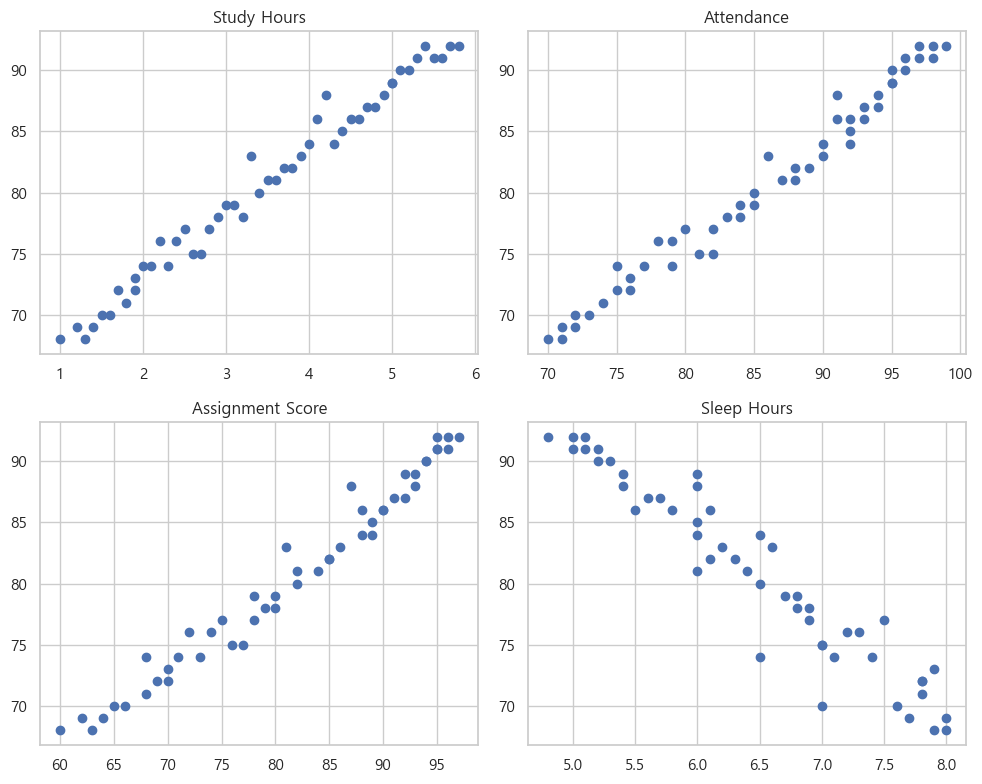

In [24]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.scatter(df['study_hours'], df['final_score'])
plt.title('Study Hours')

plt.subplot(2,2,2)
plt.scatter(df['attendance'], df['final_score'])
plt.title("Attendance")

plt.subplot(2,2,3)
plt.scatter(df['assignment_score'], df['final_score'])
plt.title('Assignment Score')

plt.subplot(2,2,4)
plt.scatter(df['sleep_hours'], df['final_score'])
plt.title('Sleep Hours')

plt.tight_layout()

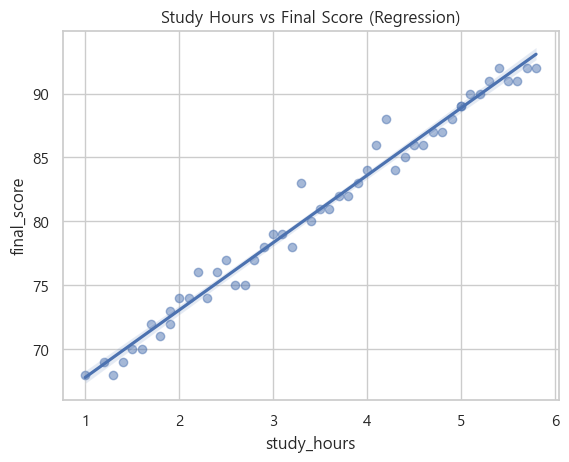

In [33]:
sns.regplot(
    x='study_hours',
    y='final_score',
    data=df,
    scatter_kws={'alpha':0.5}
)
plt.title('Study Hours vs Final Score (Regression)')
plt.show()

                  study_hours  attendance  assignment_score  sleep_hours  \
study_hours          1.000000    0.993890          0.992313    -0.965127   
attendance           0.993890    1.000000          0.996749    -0.951971   
assignment_score     0.992313    0.996749          1.000000    -0.946760   
sleep_hours         -0.965127   -0.951971         -0.946760     1.000000   
final_score          0.990312    0.988220          0.985193    -0.956436   

                  final_score  
study_hours          0.990312  
attendance           0.988220  
assignment_score     0.985193  
sleep_hours         -0.956436  
final_score          1.000000  


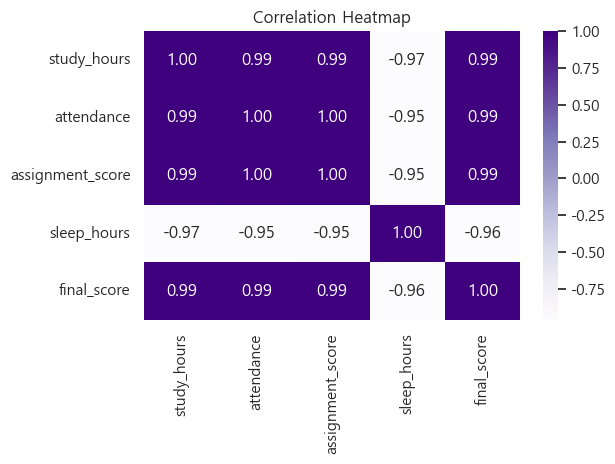

In [40]:
corr = df[['study_hours', 'attendance', 'assignment_score', 'sleep_hours', 'final_score']].corr()
print(corr)

plt.figure()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Purples')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

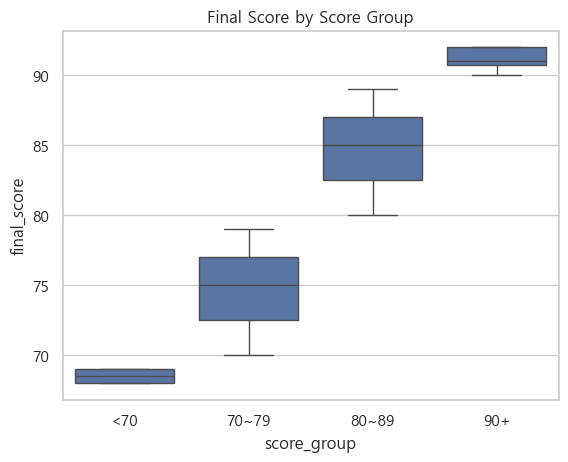

In [43]:
bins = [0,69,79,89,100]
labels = ['<70', '70~79', '80~89', '90+']

df['score_group'] = pd.cut(df['final_score'], bins=bins, labels=labels)

sns.boxplot(
    x='score_group',
    y='final_score',
    data=df
)
plt.title('Final Score by Score Group')
plt.show()